<a href="https://colab.research.google.com/github/MiguelAtencio/deep-learning-copilot/blob/main/ML4BI_E6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for BI 2

## Deep Learning exercises for week 5

In this exercise, you'll expand on last weeks exercise by adding pre-trained models to the mix. In particular, you'll work with ResNet50, a powerful pre-trained model.

Here is the task: Try a ResNet50 with data augmentation on the cifar10 dataset.

Two tips:



1.   Remember to turn on the GPU. Don't let it stand idle. Whenever you need to take a break, remember to switch it off ("disconnect and delete runtime")
2.   When preprocessing the model, do this to avoid errors

```
# Apply the preprocess_input function
x = Lambda(preprocess_input)(x)
```

This allows arbitrary expressions to be inserted into Keras models.





In [43]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Lambda, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Class names in the CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [2]:
indices = np.arange(len(train_images))
np.random.seed(42)  # For reproducibility
np.random.shuffle(indices)

train_images = train_images[indices]
train_labels = train_labels[indices]

val_size = int(0.2 * len(train_images))
val_images = train_images[:val_size]
val_labels = train_labels[:val_size]
train_images = train_images[val_size:]
train_labels = train_labels[val_size:]

print(f"Training set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")

Training set size: 40000
Validation set size: 10000


## Useful functions

In [65]:
def print_best_val_loss_and_accuracy(history):
    history_dict = history.history

    # Find the index of the best validation loss
    best_val_loss_index = np.argmin(history_dict['val_loss'])

    # Retrieve the best validation loss
    best_val_loss = history_dict['val_loss'][best_val_loss_index]

    # Retrieve the validation accuracy corresponding to the best validation loss
    best_val_accuracy = history_dict['val_accuracy'][best_val_loss_index]

    print(f"Best Validation Loss: {best_val_loss}")
    print(f"Validation Accuracy at Best Loss: {best_val_accuracy}")

def plot_accuracy_and_loss(history):

    # Extract data from history
    history_dict = history.history

    train_loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    train_accuracy = history_dict['accuracy']
    val_accuracy = history_dict['val_accuracy']

    epochs = range(1, len(train_loss) + 1)

    # Plot
    plt.figure(figsize=(14, 5))

    # Training and validation loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Training and validation accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()  # Adjusts the plots to ensure they don't overlap
    plt.show()

## ResNet 50

In [3]:
import keras_hub

conv_base = keras_hub.models.ResNetBackbone.from_preset(
    "resnet_50_imagenet"
)
conv_base.trainable = False

In [4]:
preprocessor = keras_hub.layers.ImageConverter.from_preset("resnet_50_imagenet", image_size=(32, 32))

## Fast extraction

In [5]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []

    for images, labels in dataset:
        features = conv_base(preprocessor(images))
        all_features.append(features)
        all_labels.append(labels)

    return np.concatenate(all_features), np.concatenate(all_labels)

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(128)
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(128)
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(128)

In [7]:
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(val_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [9]:
train_features.shape

(40000, 1, 1, 2048)

In [17]:
inputs = keras.Input(shape=train_features.shape[1:])
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = keras.Model(inputs, outputs)

In [18]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

callbacks = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

history = model.fit(train_features, train_labels, batch_size=256, epochs=30, validation_data=(val_features, val_labels), callbacks=callbacks)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6319 - loss: 1.0708 - val_accuracy: 0.7087 - val_loss: 0.8396
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7350 - loss: 0.7628 - val_accuracy: 0.7243 - val_loss: 0.8024
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7739 - loss: 0.6437 - val_accuracy: 0.7192 - val_loss: 0.8157
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8105 - loss: 0.5444 - val_accuracy: 0.7164 - val_loss: 0.8345
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8400 - loss: 0.4642 - val_accuracy: 0.7222 - val_loss: 0.8394
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8690 - loss: 0.3915 - val_accuracy: 0.7224 - val_loss: 0.8711
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8884 - loss: 0.3330 - val_accuracy: 0.7162 - val_loss: 0.9123
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9050 - loss: 0.2840 - val_accuracy: 0

### Accuracy 

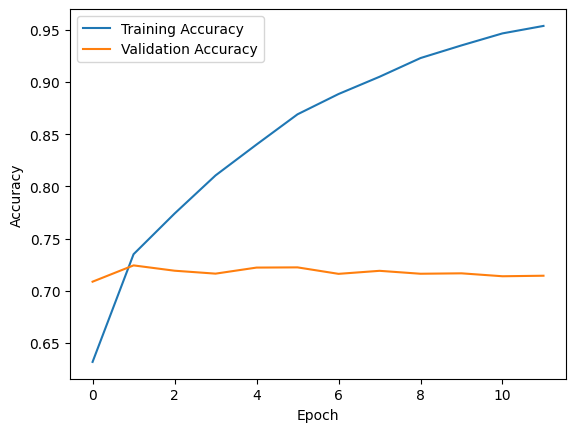

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

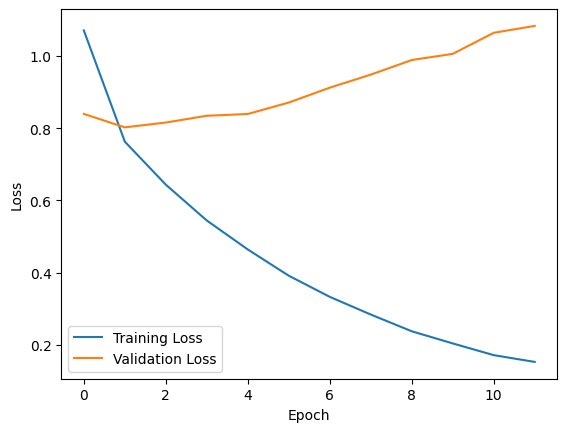

In [20]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

It appears that the data overfits very quickly 

## Extract and augment

In [42]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

### Data augmentation

In [50]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

In [51]:
base_model = keras.applications.ResNet50(include_top=False,
                                         weights='imagenet',
                                         input_shape=(32, 32, 3))

base_model.trainable = False

# Define the input tensor for your model
input_tensor = Input(shape=(32, 32, 3))

# Data augmentation
x = data_augmentation(input_tensor)

# Preprocess input function
x = Lambda(preprocess_input)(x)

# Add custom layers on top of the base model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
predictions = Dense(10, activation='softmax')(x)


# Model
model = Model(inputs=input_tensor, outputs=predictions)

In [47]:
model.compile(optimizer="Adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [48]:
callbacks = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
             keras.callbacks.ModelCheckpoint(filepath="resnet50.keras", save_best_only=True, monitor="val_accuracy")]

In [49]:
history = model.fit(x_train, y_train, batch_size=256, 
                    epochs=40, validation_split=0.2, 
                    callbacks=callbacks, verbose=1)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.4392 - loss: 1.7299 - val_accuracy: 0.5868 - val_loss: 1.1735
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.5126 - loss: 1.3875 - val_accuracy: 0.6045 - val_loss: 1.1212
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.5330 - loss: 1.3158 - val_accuracy: 0.6210 - val_loss: 1.0829
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5467 - loss: 1.2857 - val_accuracy: 0.6167 - val_loss: 1.0923
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.5517 - loss: 1.2614 - val_accuracy: 0.6256 - val_loss: 1.0593
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.5615 - loss: 1.2388 - val_accuracy: 0.6230 - val_loss: 1.0656
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.5671 - loss: 1.2252 - val_accuracy: 0.6361 - val_loss: 1.0396
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5691 - loss: 1.2103 - val_acc

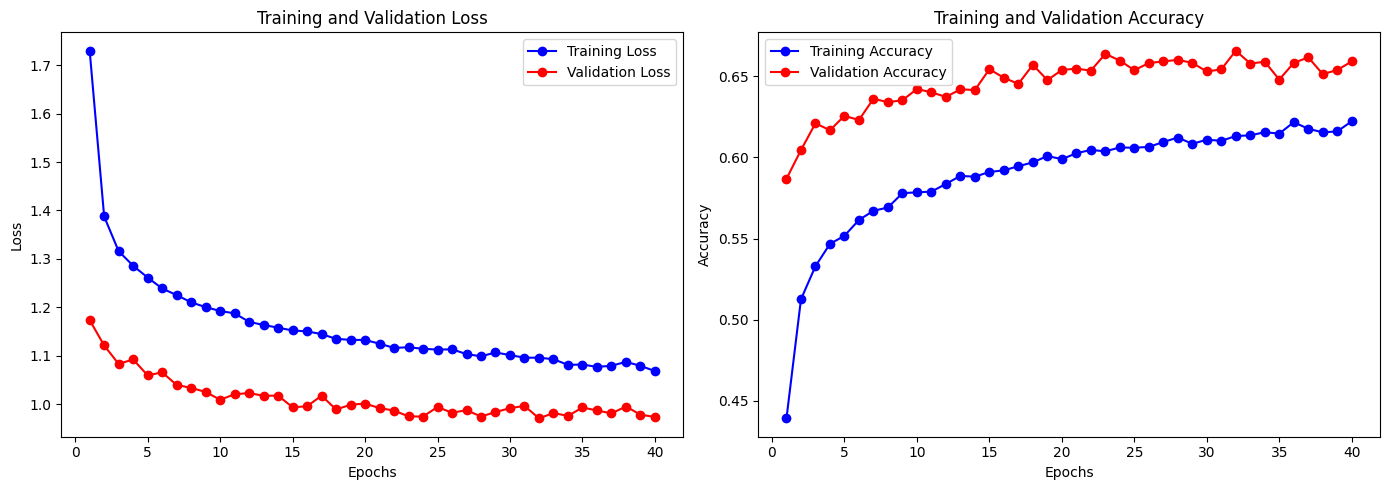

In [52]:
history_dict = history.history

# Extracting loss and accuracy history
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Plotting training and validation loss
plt.figure(figsize=(14, 5))

# Training and validation loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Training and validation accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()  # Adjusts the plots to ensure they don't overlap
plt.show()

In [53]:
def print_best_val_loss_and_accuracy(history):
    history_dict = history.history

    # Find the index of the best validation loss
    best_val_loss_index = np.argmin(history_dict['val_loss'])

    # Retrieve the best validation loss
    best_val_loss = history_dict['val_loss'][best_val_loss_index]

    # Retrieve the validation accuracy corresponding to the best validation loss
    best_val_accuracy = history_dict['val_accuracy'][best_val_loss_index]

    print(f"Best Validation Loss: {best_val_loss}")
    print(f"Validation Accuracy at Best Loss: {best_val_accuracy}")

In [54]:
print_best_val_loss_and_accuracy(history)

Best Validation Loss: 0.9706191420555115
Validation Accuracy at Best Loss: 0.6657000184059143


# Fine tuning

In [55]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Lambda, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Class names in the CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [56]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [70]:
base_model = keras.applications.ResNet50(include_top=False,
                                         weights='imagenet',
                                         input_shape=(32, 32, 3))

base_model.trainable = False

# Define the input tensor for your model
input_tensor = Input(shape=(32, 32, 3))
# Preprocess input function
x = Lambda(preprocess_input)(input_tensor)

# Add custom layers on top of the base model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
predictions = Dense(10, activation='softmax')(x)

# Model
model = Model(inputs=input_tensor, outputs=predictions)

In [71]:
model.compile(optimizer="Adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [72]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath="fine_tuned_resnet50.keras", save_best_only=True, monitor="val_loss")]

In [73]:
history = model.fit(x_train, y_train, batch_size=256, 
                    epochs=100, validation_split=0.2,
                    callbacks=callbacks, verbose=1)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.5471 - loss: 1.4099 - val_accuracy: 0.6312 - val_loss: 1.0468
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6506 - loss: 0.9976 - val_accuracy: 0.6530 - val_loss: 0.9925
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6910 - loss: 0.8741 - val_accuracy: 0.6603 - val_loss: 0.9801
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7232 - loss: 0.7787 - val_accuracy: 0.6703 - val_loss: 0.9744
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7481 - loss: 0.7031 - val_accuracy: 0.6719 - val_loss: 0.9726
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7734 - loss: 0.6276 - val_accuracy: 0.6720 - val_loss: 0.9939
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7994 - loss: 0.5632 - val_accuracy: 0.6734 - val_loss: 1.0106
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8213 - loss: 0.5003 -

In [74]:
print_best_val_loss_and_accuracy(history)

Best Validation Loss: 0.9726317524909973
Validation Accuracy at Best Loss: 0.6718999743461609


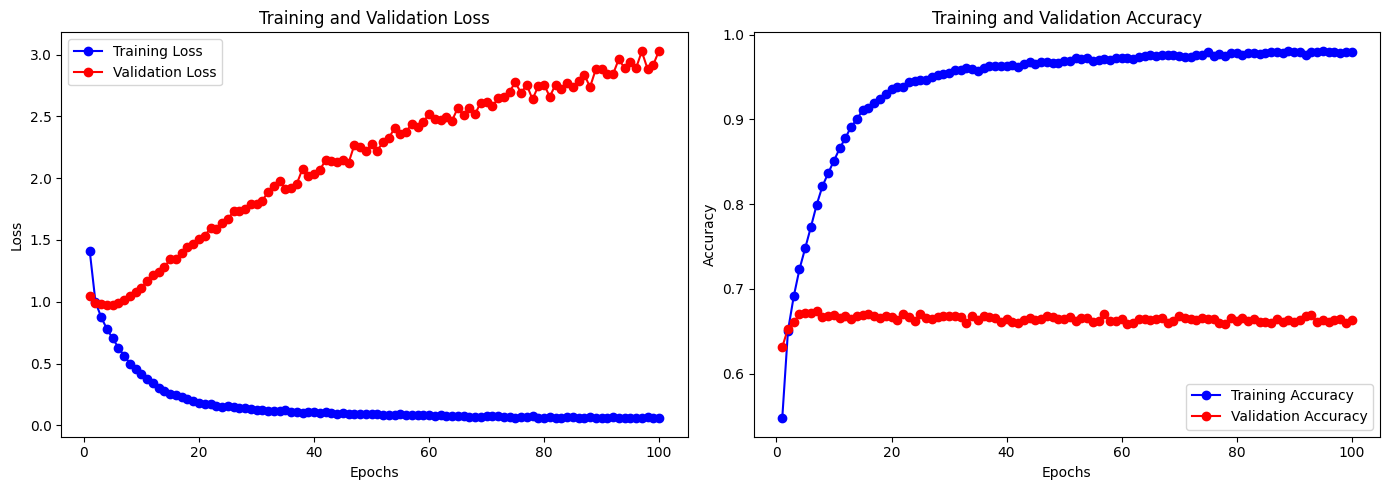

In [75]:
plot_accuracy_and_loss(history)